# [LAB 06] 9. Pie・Donut Plot

## #01. 준비작업

### 1. 패키지 참조

In [1]:
from jussam import load_data
from helpers import *
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기

In [2]:
origin = load_data("cafe_sales")
origin.head()

📚 서울의 한 오피스 상권 카페에서 점심시간(11:30~13:30) 동안 판매된 음료 주문 데이터


,주문번호,주문시각,구분,메뉴명,사이즈,금액
0,1001,2026-03-31 11:32,커피,아메리카노,레귤러,4500
1,1002,2026-03-31 11:34,커피,카페라떼,레귤러,5000
2,1003,2026-03-31 11:35,커피,아메리카노,라지,5000
3,1004,2026-03-31 11:36,커피,콜드브루,레귤러,5300
4,1005,2026-03-31 11:38,에이드,자몽에이드,레귤러,5800


### 3. 데이터 전처리

- 필요한 컬럼만 추출하여 메뉴별 합계 금액을 산정 후 금액이 높은 순으로 정렬
  - seaborn은 데이터에 대한 집계를 자동으로 처리해 주지만,        
  pyplot을 사용한 시각화는 분석가가 시각화에 적합한 전처리를 직접 수행해야 한다.

In [3]:
df1 = origin[['메뉴명', '금액']].groupby('메뉴명').sum()
df1.sort_values('금액', ascending=False, inplace=True)
df1.head()

,금액
메뉴명,
아메리카노,60000
콜드브루,43400
카페라떼,41000
자몽에이드,35800
녹차,24500


## #02. PiePlot 시각화

### 1. 기본 구현

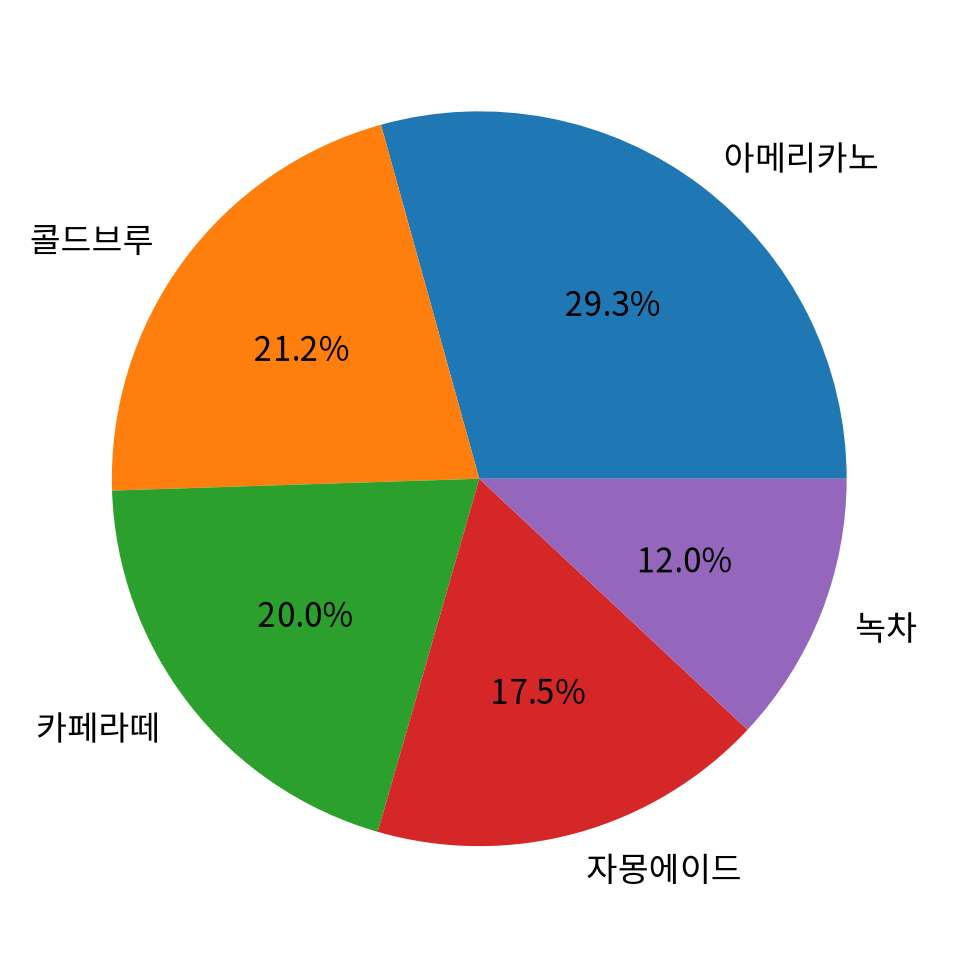

In [4]:
fig, ax = my_plot.init(width=500, height=500)
ax.pie(x=df1['금액'],       # 파이 차트로 표현할 데이터
       labels=df1.index,    # 각 데이터에 대한 레이블
       autopct='%.1f%%'     # 각 데이터의 비율을 표시 단위
)
my_plot.show()

### 2. 그래프 회전

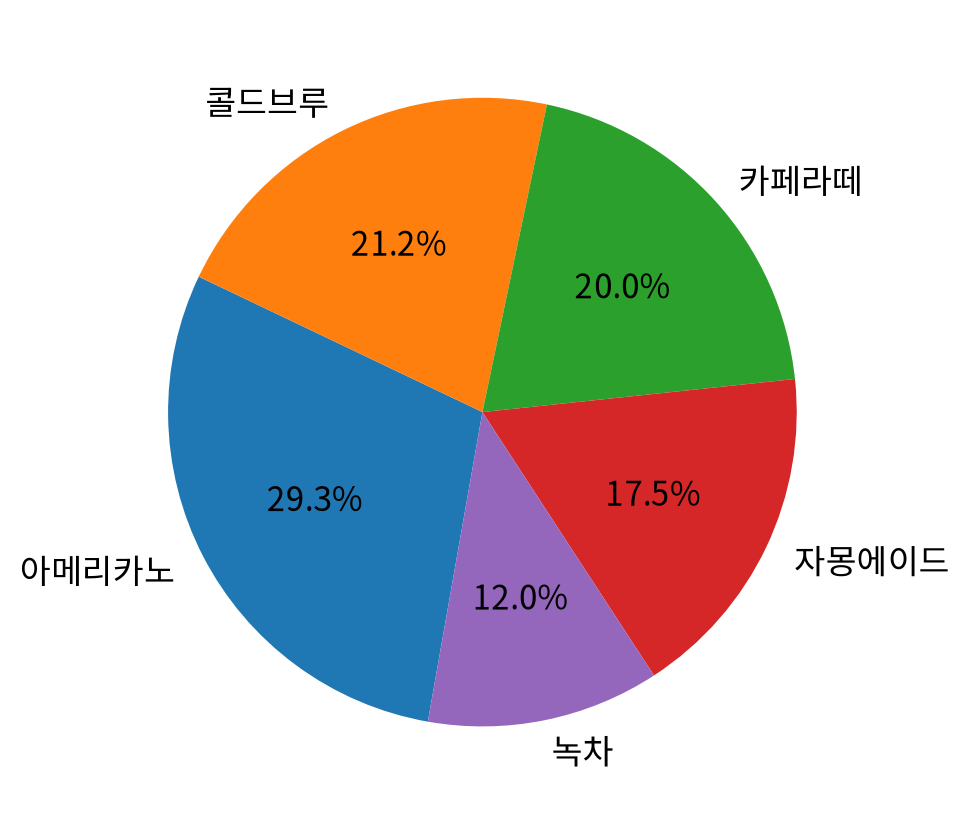

In [5]:
fig, ax = my_plot.init(width=500, height=500)
ax.pie(x=df1['금액'],       # 파이 차트로 표현할 데이터
       labels=df1.index,    # 각 데이터에 대한 레이블
       autopct='%.1f%%',    # 각 데이터의 비율을 표시 단위
       startangle=260,      # 파이 차트의 시작 각도
       counterclock=False   # 시계방향으로 그리도록 설정 (기본값=반시계방향)
)
my_plot.show()

### 3. 색상값 생성하기

- seaborn은 팔레트 이름을 지정하면 처리되지만 pyplot은 데이터 수 만큼의 색상값을 원소로 갖는 리스트를 정의해야 한다.

In [6]:
colors = sb.color_palette("Set2", n_colors=len(df1['금액']))
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235)]

### 4. 색상값 설정하기

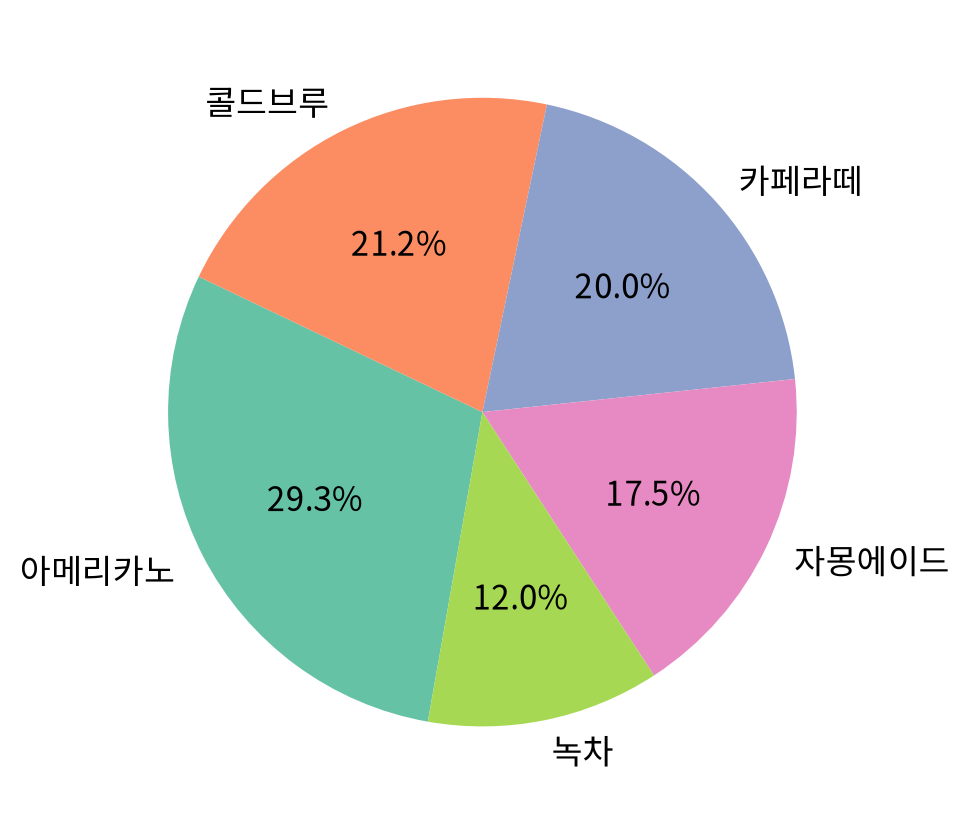

In [7]:
fig, ax = my_plot.init(width=500, height=500)
ax.pie(x=df1['금액'],       # 파이 차트로 표현할 데이터
       labels=df1.index,    # 각 데이터에 대한 레이블
       autopct='%.1f%%',    # 각 데이터의 비율을 표시 단위
       startangle=260,      # 파이 차트의 시작 각도
       counterclock=False,  # 시계방향으로 그리도록 설정 (기본값=반시계방향)
       colors=colors)       # 각 데이터에 대한 색상
my_plot.show()

### 5. 특정 항목을 중심에서 분리하기

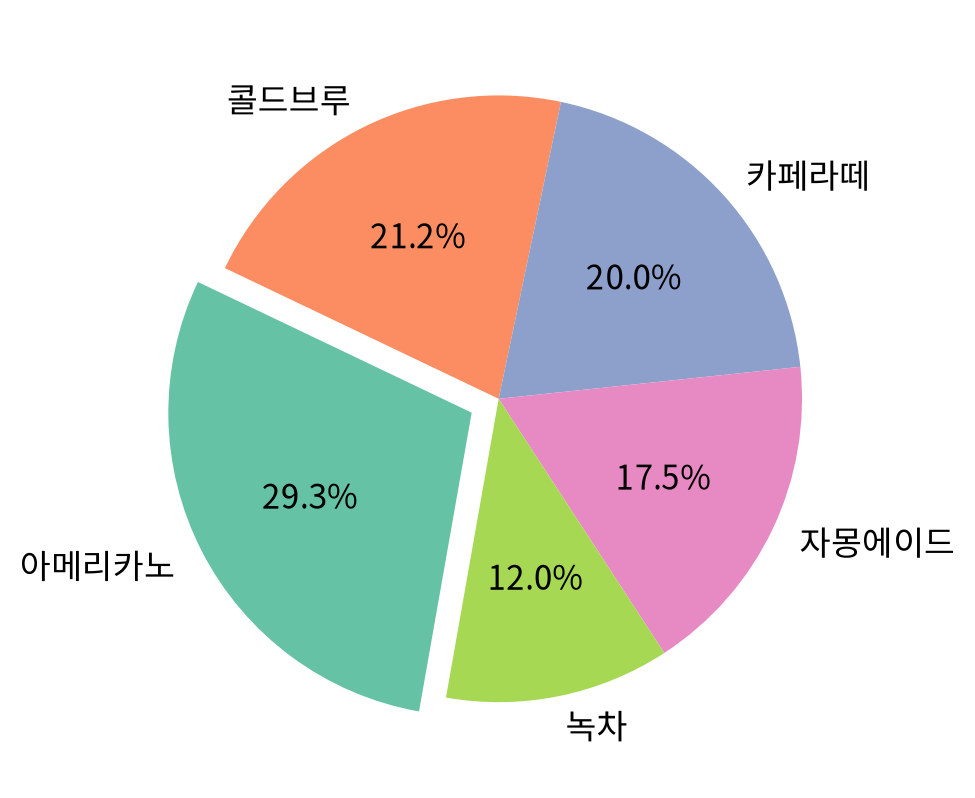

In [8]:
# 중심과의 거리를 데이터 순서대로 정의 (0~1 사이의 값)
# -> 데이터 수와 동일한 길이의 리스트로 정의
explode = [0.1, 0, 0, 0, 0]

fig, ax = my_plot.init(width=500, height=500)
ax.pie(x=df1['금액'],       # 파이 차트로 표현할 데이터
       labels=df1.index,    # 각 데이터에 대한 레이블
       autopct='%.1f%%',    # 각 데이터의 비율을 표시 단위
       startangle=260,      # 파이 차트의 시작 각도
       counterclock=False,  # 시계방향으로 그리도록 설정 (기본값=반시계방향)
       colors=colors,       # 각 데이터에 대한 색상
       explode=explode)     # 중심과의 거리를 데이터 순서대로 정의
my_plot.show()

## #03. Donut Plot

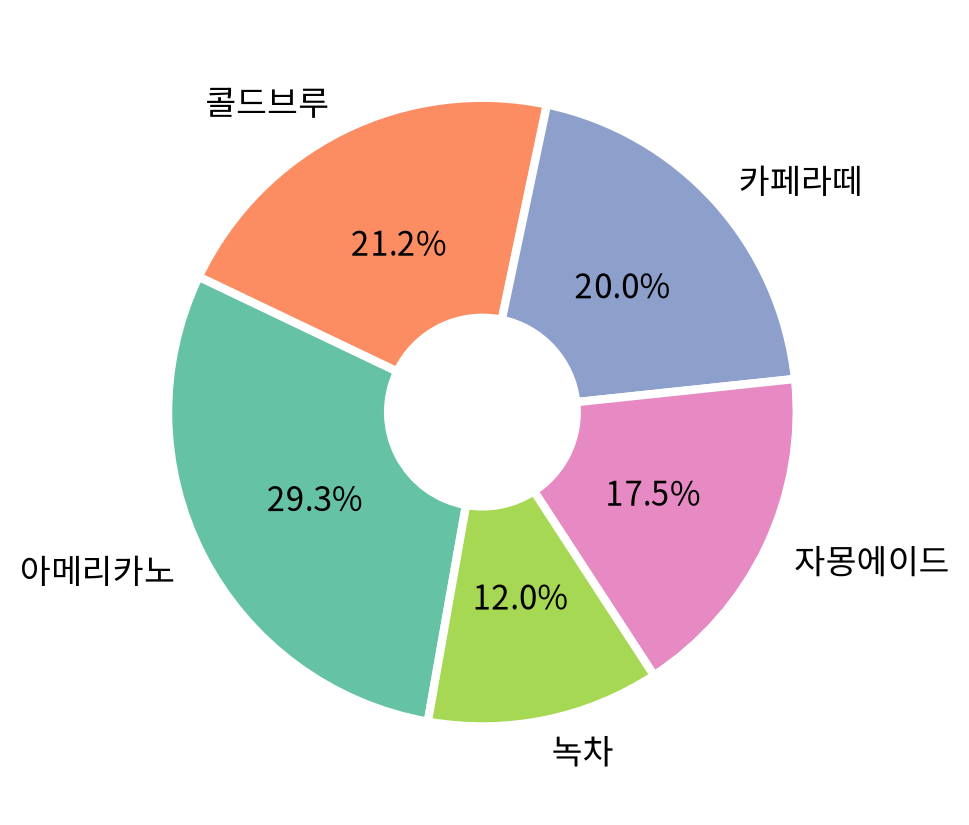

In [9]:
# 파이 차트의 조각(wedge) 스타일을 설정하는 딕셔너리
# -> 두께, 테두리 색상, 테두리 두께
wedgeprops={'width': 0.7, 'edgecolor': '#ffffff', 'linewidth': 3}

fig, ax = my_plot.init(width=500, height=500)
ax.pie(x=df1['금액'],        # 파이 차트로 표현할 데이터
       labels=df1.index,     # 각 데이터에 대한 레이블
       autopct='%.1f%%',     # 각 데이터의 비율을 표시 단위
       startangle=260,       # 파이 차트의 시작 각도
       counterclock=False,   # 시계방향으로 그리도록 설정 (기본값=반시계방향)
       colors=colors,        # 각 데이터에 대한 색상 
       wedgeprops=wedgeprops # 파이 차트의 조각 스타일 설정
)
my_plot.show()

#### 💡 인사이트

- ☕ 점심시간 매출 비중 1위는 아메리카노(29.3%)임.
- 🥶 2위는 콜드브루(21.2%), 3위는 카페라떼(20.0%)로 확인됨.
- 🍹 자몽에이드는 17.5%, 🍵 녹차는 12.0%로 나타남.
- 📊 상위 3개 메뉴(아메리카노, 콜드브루, 카페라떼) 합계는 70.5%임.
- 📉 녹차(12.0%)와 아메리카노(29.3%)의 비중 차이는 17.3%p임.
- 🔎 아메리카노와 콜드브루를 합치면 50.5%로, 전체의 절반을 넘는 비중임.

## #04. 모듈화 기능 확인

### 1. 파이 그래프

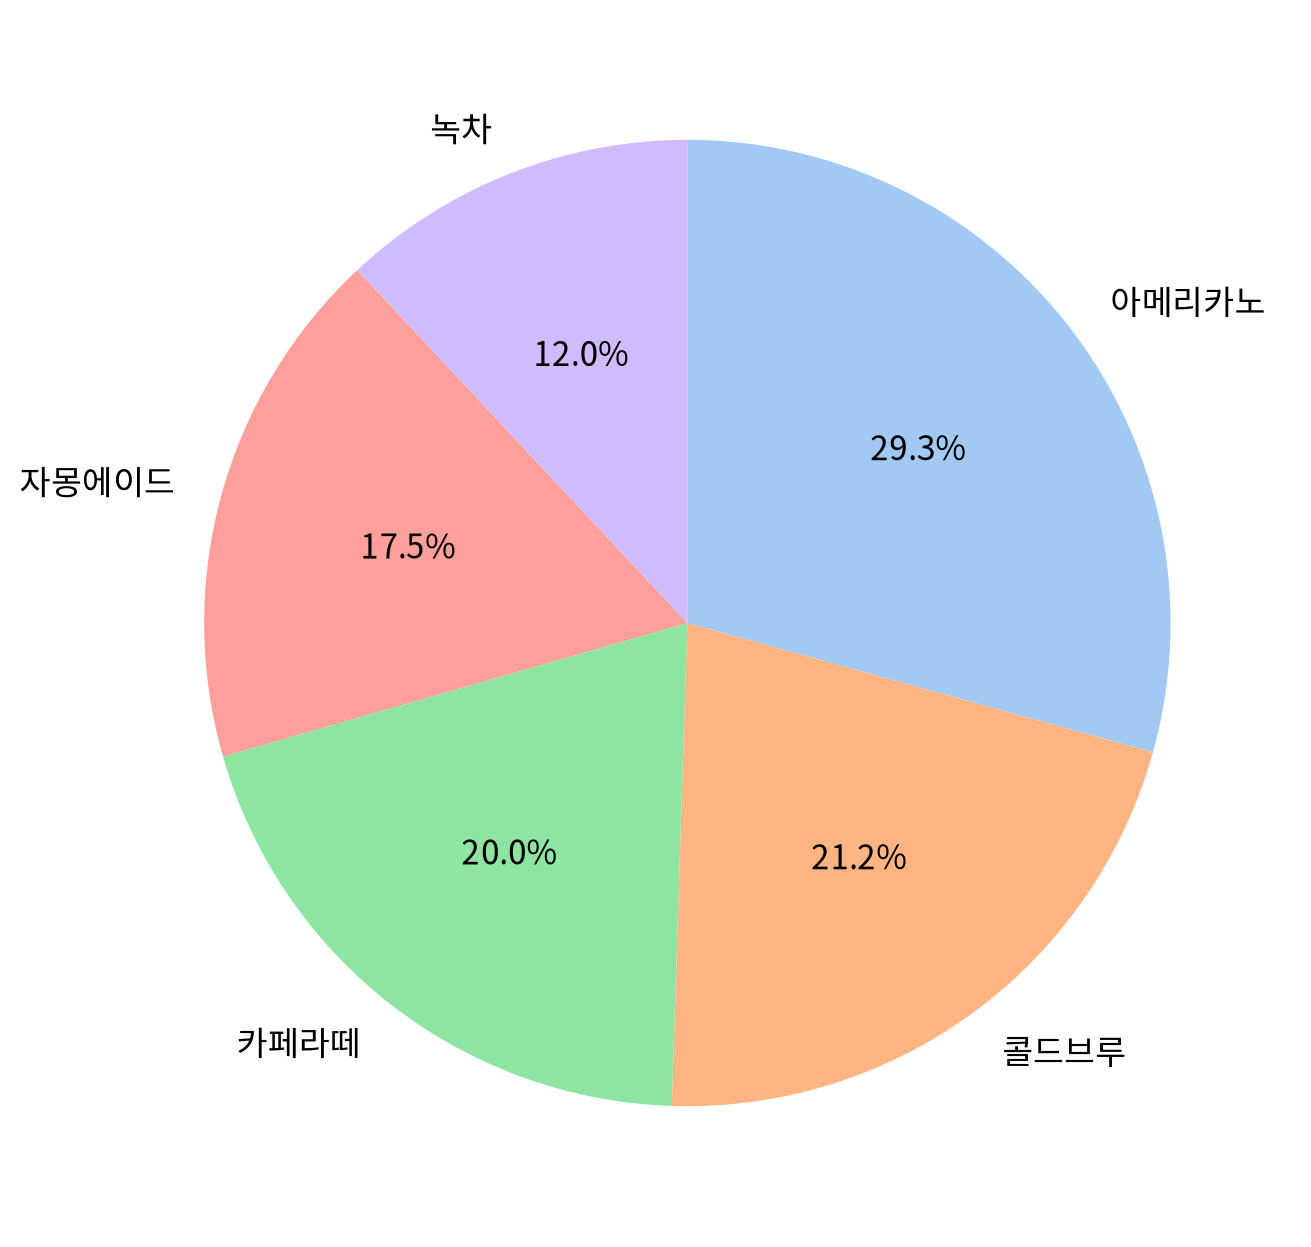

In [10]:
my_plot.pieplot(x=df1['금액'], labels=df1.index, palette="pastel")

### 2. 도넛 그래프

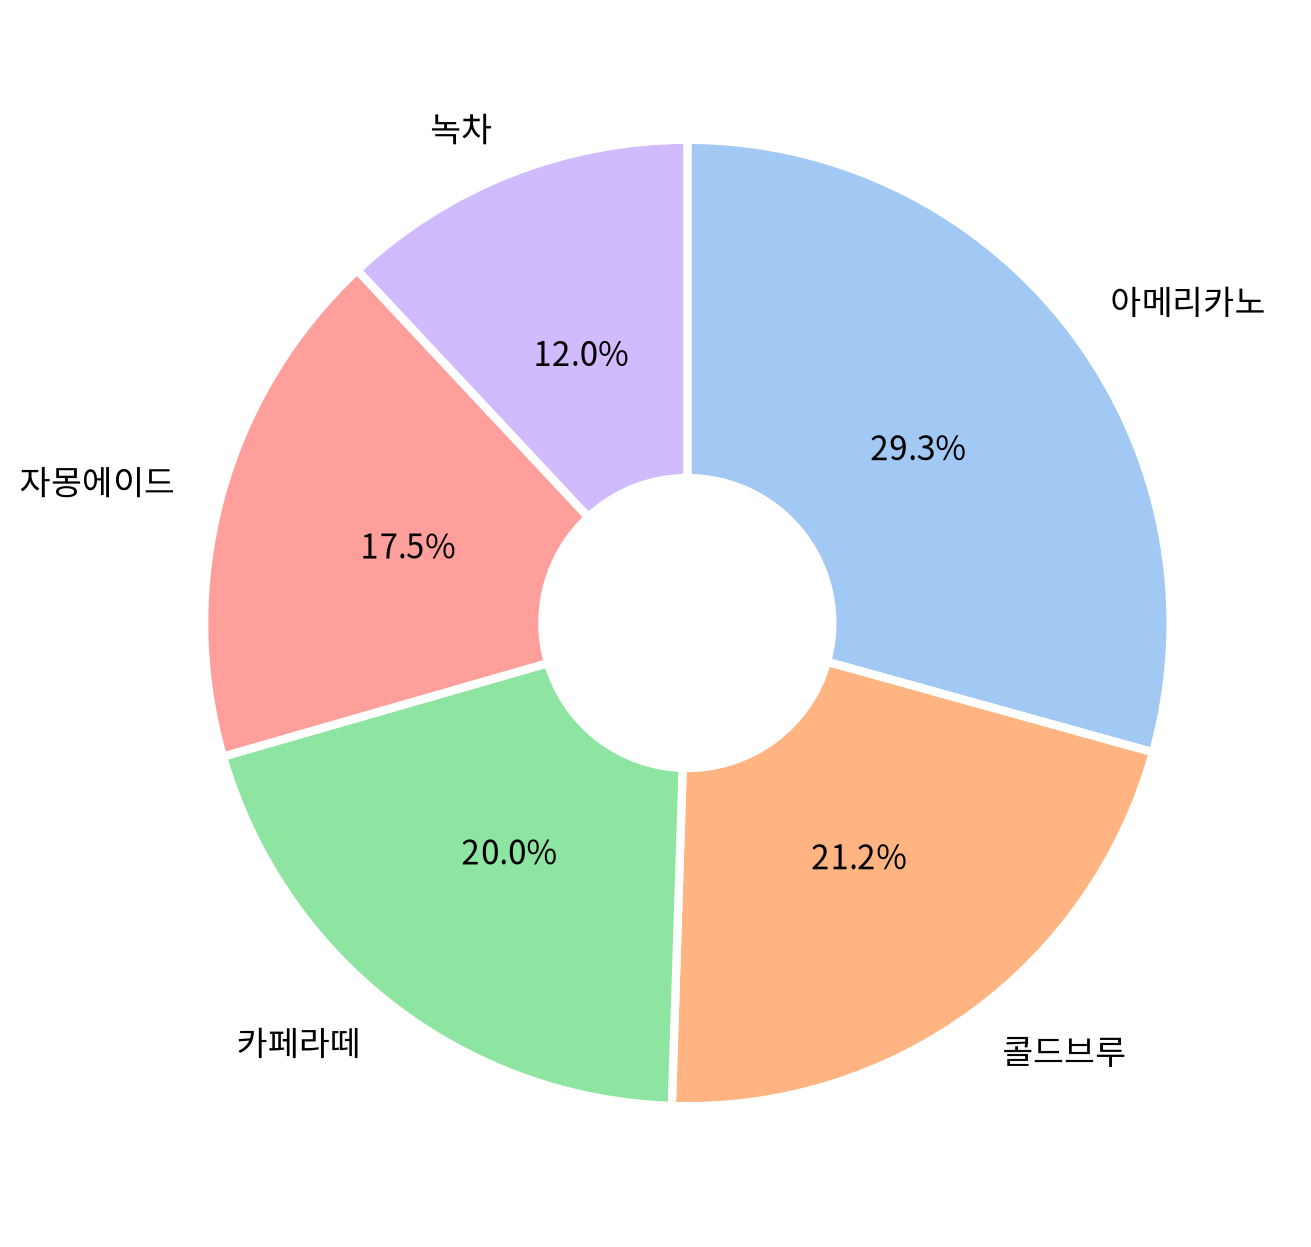

In [11]:
my_plot.pieplot(x=df1['금액'], labels=df1.index, palette="pastel", 
                donutchart=True)